**Importing Libraries**

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step 1:Data Loading and Preview**

In [3]:
dtype_mapping = {
    "DR_NO": "int32",                 # File number, fits in int32
    "Date Rptd": "str",                # Convert to datetime later
    "DATE OCC": "str",                 # Convert to datetime later
    "TIME OCC": "uint16",               # 24-hour format (0000-2359), fits in uint16
    "AREA": "uint8",                   # Geographic area ID (1-21), fits in uint8
    "AREA NAME": "category",           # Categorical division name
    "Rpt Dist No": "uint16",            # Four-digit district code
    "Part 1-2": "uint8",                # Only two values (1 or 2)
    "Crm Cd": "uint16",                 # Crime code
    "Crm Cd Desc": "category",         # Crime description
    "Mocodes": "category",             # Categorical (modality of crime)
    "Vict Age": "uint8",                # Age is small, fits in uint8 (0-255)
    "Vict Sex": "category",            # Categorical (M, F, X)
    "Vict Descent": "category",        # Categorical (A, B, C, etc.)
    "Premis Cd": "float32",            # Premises code (could contain NaN)
    "Premis Desc": "category",         # Description of the premises
    "Weapon Used Cd": "float32",       # Weapon code (could contain NaN)
    "Weapon Desc": "category",         # Description of weapon used
    "Status": "category",              # Case status (e.g., IC)
    "Status Desc": "category",         # Case status description
    "Crm Cd 1": "float32",             # Primary crime committed (could be NaN)
    "Crm Cd 2": "float32",             # Additional crime (less serious)
    "Crm Cd 3": "float32",             # Additional crime (less serious)
    "Crm Cd 4": "float32",             # Additional crime (less serious)
    "LOCATION": "category",            # Address of the crime (rounded)
    "Cross Street": "category",        # Cross street of the crime
    "LAT": "float32",                  # Latitude coordinate
    "LON": "float32"                   # Longitude coordinate
}

In [4]:
#Dataset Loading
dataset_path1 = r'/content/drive/MyDrive/Crime Prediction/LA/Crime_Data_from_2010_to_2019.csv'
dataset_path2 = r'/content/drive/MyDrive/Crime Prediction/LA/Crime_Data_from_2020_to_Present.csv'

# Loading dataset with dtype mapping and only required columns
dataset1 = pd.read_csv(dataset_path1,dtype=dtype_mapping)
dataset2 = pd.read_csv(dataset_path2,dtype=dtype_mapping)

In [5]:
print(dataset1.columns)  # Verify column order
print(dataset2.columns)  # Verify column order

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA ', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')
Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')


In [6]:
# Standardize column names (strip spaces and make lowercase for consistency)
dataset1.columns = dataset1.columns.str.strip()
dataset2.columns = dataset2.columns.str.strip()

dataset = pd.concat([dataset1[dataset1.columns], dataset2[dataset2.columns]], ignore_index=True)
print(f"Final Merged Dataset Shape: {dataset.shape}")
print("Columns in Merged Dataset:")
print(dataset.columns)

Final Merged Dataset Shape: (3265650, 28)
Columns in Merged Dataset:
Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')


In [7]:
# Display memory usage
print(f"Memory usage: {dataset.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Memory usage: 2139.37 MB


In [8]:
#Columns in dataset
dataset.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [9]:
dataset.head(3)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,1307355,02/20/2010 12:00:00 AM,02/20/2010 12:00:00 AM,1350,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,...,AA,Adult Arrest,900.0,NaN,NaN,NaN,300 E GAGE AV,NaN,33.982498,-118.269501
1,11401303,09/13/2010 12:00:00 AM,09/12/2010 12:00:00 AM,45,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,Invest Cont,740.0,NaN,NaN,NaN,SEPULVEDA BL,MANCHESTER AV,33.959900,-118.396202
2,70309629,08/09/2010 12:00:00 AM,08/09/2010 12:00:00 AM,1515,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,...,IC,Invest Cont,946.0,NaN,NaN,NaN,1300 E 21ST ST,NaN,34.022400,-118.252403


In [10]:
#Finding Data types of Attributes
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265650 entries, 0 to 3265649
Data columns (total 28 columns):
 #   Column          Dtype   
---  ------          -----   
 0   DR_NO           int32   
 1   Date Rptd       object  
 2   DATE OCC        object  
 3   TIME OCC        uint16  
 4   AREA            int64   
 5   AREA NAME       category
 6   Rpt Dist No     uint16  
 7   Part 1-2        uint8   
 8   Crm Cd          uint16  
 9   Crm Cd Desc     object  
 10  Mocodes         object  
 11  Vict Age        uint8   
 12  Vict Sex        object  
 13  Vict Descent    category
 14  Premis Cd       float32 
 15  Premis Desc     object  
 16  Weapon Used Cd  float32 
 17  Weapon Desc     category
 18  Status          object  
 19  Status Desc     category
 20  Crm Cd 1        float32 
 21  Crm Cd 2        float32 
 22  Crm Cd 3        float32 
 23  Crm Cd 4        float32 
 24  LOCATION        object  
 25  Cross Street    object  
 26  LAT             float32 
 27  LON         

**Step 2 : Data Cleaning and Formating**

In [11]:
dataset.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [12]:
#Removing Features that are not necessary for EDA
features = [
    'DR_NO', 'Date Rptd', 'Rpt Dist No', 'Mocodes', 'Premis Cd', 'Weapon Used Cd', 'Status', 'Crm Cd 1'
]

# Filter the dataset to keep only the necessary columns
dst = dataset.drop(features,axis=1)

In [13]:
# Convert date columns (modify column names if necessary)
date_columns = ['DATE OCC']  # Ensure these column names match exactly
for col in date_columns:
    dst[col] = pd.to_datetime(dst[col], errors='coerce')

# Convert 'TIME OCC' to HH:MM format
dst["TIME OCC"] = dst["TIME OCC"].astype(str).str.zfill(4)  # Ensure 4 digits (e.g., 930 → 0930)
dst["TIME OCC"] = dst["TIME OCC"].str[:2] + ":" + dst["TIME OCC"].str[2:]  # Convert to HH:MM format

# Check if any dates failed to convert
print(dst[date_columns].dtypes)


DATE OCC    datetime64[ns]
dtype: object


In [14]:
#Dropping Duplicate Instances
print("Number of Duplicates to be removed",dst.duplicated().sum())
dataset = dst.drop_duplicates()
print("Shape of dataset after duplicate removal",dataset.shape)

#Removing records from dataset where there is abnormal value in Vict Descent
abnormal_values = dataset[dataset["Vict Descent"] =="-"].shape[0]
print("Abnormal values count",abnormal_values)
dataset = dataset[dataset["Vict Descent"] != "-"]

#Shape of dataset after removing abnormal values
print("Shape of dataset after abnormal values removal",dataset.shape)

Number of Duplicates to be removed 178562
Shape of dataset after duplicate removal (3087088, 20)
Abnormal values count 5
Shape of dataset after abnormal values removal (3087083, 20)


In [15]:
dataset.head(3)

,DATE OCC,TIME OCC,AREA,AREA NAME,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Desc,Weapon Desc,Status Desc,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,2010-02-20,13:50,13,Newton,2,900,VIOLATION OF COURT ORDER,48,M,H,SINGLE FAMILY DWELLING,NaN,Adult Arrest,NaN,NaN,NaN,300 E GAGE AV,NaN,33.982498,-118.269501
1,2010-09-12,00:45,14,Pacific,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0,M,W,STREET,NaN,Invest Cont,NaN,NaN,NaN,SEPULVEDA BL,MANCHESTER AV,33.959900,-118.396202
2,2010-08-09,15:15,13,Newton,2,946,OTHER MISCELLANEOUS CRIME,0,M,H,ALLEY,NaN,Invest Cont,NaN,NaN,NaN,1300 E 21ST ST,NaN,34.022400,-118.252403


**Step 3: Handling Missing Data**

In [16]:
#Checking for Missing Values
dataset.isnull().sum()

,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,336527
Vict Descent,336585


In [17]:
missing_values = dataset.isnull().sum()
#Predicting missing values percentage in each column
missing_percentage = (missing_values / len(dataset)) * 100

# Display only columns with missing values
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_data = missing_data[missing_data['Missing Values'] > 0]  # Show only non-zero missing columns

print(missing_data)

              Missing Values  Percentage
Vict Sex              336527   10.901132
Vict Descent          336585   10.903011
Premis Desc              773    0.025040
Weapon Desc          2059169   66.702742
Crm Cd 2             2879652   93.280680
Crm Cd 3             3081319   99.813287
Crm Cd 4             3086915   99.994558
Cross Street         2582871   83.667041


In [18]:
threshold = 50 #threshold value in percentage to decide whether feature has to be removed or imputed

# Features to be removed
features_to_remove = missing_percentage[missing_percentage > threshold].index.tolist()

# Features to impute
features_to_impute = missing_percentage[(missing_percentage > 0) & (missing_percentage <= threshold)].index.tolist()

# Print results
print("Features to Remove (Too Many Missing Values):")
print(features_to_remove, "\n")

print("Features to Impute (Moderate Missing Values):")
print(features_to_impute, "\n")

#Imputation strategy
for feature in features_to_impute:
    if dataset[feature].dtype == 'object':  # Categorical feature
        print(f"{feature}: Imputing with Mode or'Unknown'")
    else:  # Numerical feature
        print(f"{feature}: Imputing with Mean/Mode")

Features to Remove (Too Many Missing Values):
['Weapon Desc', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street'] 

Features to Impute (Moderate Missing Values):
['Vict Sex', 'Vict Descent', 'Premis Desc'] 

Vict Sex: Imputing with Mode or'Unknown'
Vict Descent: Imputing with Mean/Mode
Premis Desc: Imputing with Mode or'Unknown'


In [19]:
#dropping features that has too many missing values
dataset = dataset.drop(features_to_remove,axis=1)

In [41]:
dataset.head()

,DATE OCC,TIME OCC,AREA,AREA NAME,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,...,LON,Year,Month,Day of Week,Season,Crime Shift,Lat Group,Lon Group,Victim Age Group,Crime Type
0,2010-02-20,13:50,13,Newton,2,900,VIOLATION OF COURT ORDER,48,M,H,...,-118.269501,2010,February,Saturday,Winter,Afternoon,33.980000,-118.269997,Adult,Other Crime
1,2010-09-12,00:45,14,Pacific,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0,M,W,...,-118.396202,2010,September,Sunday,Fall,Midnight,33.959999,-118.400002,Minor,Property Crime
2,2010-08-09,15:15,13,Newton,2,946,OTHER MISCELLANEOUS CRIME,0,M,H,...,-118.252403,2010,August,Monday,Summer,Afternoon,34.020000,-118.250000,Minor,Other Crime
3,2010-01-05,01:50,6,Hollywood,2,900,VIOLATION OF COURT ORDER,47,F,W,...,-118.329498,2010,January,Tuesday,Winter,Midnight,34.099998,-118.330002,Adult,Other Crime
4,2010-01-02,21:00,1,Central,1,122,"RAPE, ATTEMPTED",47,F,H,...,-118.248802,2010,January,Saturday,Winter,Night,34.040001,-118.250000,Adult,Sex Crime


In [42]:
dataset.columns

Index(['DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Part 1-2', 'Crm Cd',
       'Crm Cd Desc', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Desc',
       'Status Desc', 'LOCATION', 'LAT', 'LON', 'Year', 'Month', 'Day of Week',
       'Season', 'Crime Shift', 'Lat Group', 'Lon Group', 'Victim Age Group',
       'Crime Type'],
      dtype='object')

In [20]:
# Function to safely fill missing values using mode
def safe_mode_impute(series):
    mode_value = series.mode()
    return series.fillna(mode_value.iloc[0] if not mode_value.empty else "Unknown")

def impute_categorical(dataset, column, groupby_col):
    dataset[column] = dataset.groupby(groupby_col)[column].transform(safe_mode_impute)

In [21]:
# Apply to multiple columns
impute_categorical(dataset, "Vict Sex", "Crm Cd")
impute_categorical(dataset, "Vict Descent", "AREA")
impute_categorical(dataset, "Premis Desc", "AREA")

In [22]:
dataset.isnull().sum()

,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,0
Vict Descent,0


**Step 4 : Feature Extraction**

Extracting Time Based Features

In [23]:
# Function to categorize crime shifts
def crime_shift(time_str):
    try:
        hour = int(str(time_str)[:2])  # Extract the first two characters as an integers
        if 6 <= hour < 12:
            return "Morning"
        elif 12 <= hour < 18:
            return "Afternoon"
        elif 18 <= hour < 24:
            return "Night"
        else:
            return "Midnight"
    except:
        return "Unknown"  # Handle missing or incorrect values

# Function to categorize seasons
def get_season(month):
    if month in ['December', 'January', 'February']:
        return "Winter"
    elif month in ['March', 'April', 'May']:
        return "Spring"
    elif month in ['June', 'July', 'August']:
        return "Summer"
    elif month in ['September', 'October', 'November']:
        return "Fall"


dataset["Year"] = dataset["DATE OCC"].dt.year
dataset["Month"] = dataset["DATE OCC"].dt.month_name()
dataset["Day of Week"] = dataset["DATE OCC"].dt.day_name()
dataset["Season"] = dataset["Month"].apply(get_season)
dataset["Crime Shift"] = dataset["TIME OCC"].apply(crime_shift)

#Aggregating crime counts
crime_per_year = dataset.groupby("Year")["Crm Cd Desc"].count()
crime_per_month = dataset.groupby("Month")["Crm Cd Desc"].count()
crime_per_day_of_week = dataset.groupby("Day of Week")["Crm Cd Desc"].count()
crime_in_season = dataset.groupby("Season")["Crm Cd Desc"].count()
crime_per_shift = dataset.groupby("Crime Shift")["Crm Cd Desc"].count()

Extracting Location Based Features

In [24]:
#Aggregating Crimes based on LA patrol divison
crimes_per_area = dataset.groupby("AREA NAME")["Crm Cd Desc"].count()

# Rounding Lat/Lon for clustering
dataset["Lat Group"] = dataset["LAT"].round(2)
dataset["Lon Group"] = dataset["LON"].round(2)

In [25]:
#Aggregating based on Premis Description
crimes_in_premis = dataset.groupby("Premis Desc")["Crm Cd Desc"].count()
print(crimes_in_premis[:10])

Premis Desc
7TH AND METRO CENTER (NOT LINE SPECIFIC)                    329
ABANDONED BUILDING ABANDONED HOUSE                         1465
ABATEMENT LOCATION                                           28
ABORTION CLINIC/ABORTION FACILITY*                           38
AIRCRAFT                                                    308
ALLEY                                                     20658
AMTRAK TRAIN                                                 57
AMUSEMENT PARK*                                              70
APARTMENT/CONDO COMMON LAUNDRY ROOM                        1040
ARCADE,GAME ROOM/VIDEO GAMES (EXAMPLE CHUCKIE CHEESE)*      158
Name: Crm Cd Desc, dtype: int64


Victim Based Features

In [26]:
# Categorizing victim age
def age_group(age):
    if age < 18:
        return "Minor"
    elif 18 <= age < 30:
        return "Young Adult"
    elif 30 <= age < 60:
        return "Adult"
    else:
        return "Senior"

dataset["Victim Age Group"] = dataset["Vict Age"].apply(age_group)
victim_descent = dataset.groupby("Vict Descent")["Crm Cd Desc"].count()

In [27]:
male_victims = dataset[dataset["Vict Sex"] == "M"].groupby("Year")["Year"].count()
female_victims = dataset[dataset["Vict Sex"] == "F"].groupby("Year")["Year"].count()

In [28]:
descent_wise_male = dataset[dataset["Vict Sex"] == "M"].groupby("Vict Descent")["Vict Descent"].count()
descent_wise_female = dataset[dataset["Vict Sex"] == "F"].groupby("Vict Descent")["Vict Descent"].count()
descent_wise_male = descent_wise_male[:-1]
descent_wise_female = descent_wise_female[:-1]

descent_victims = pd.DataFrame({"Male":descent_wise_male,"Female":descent_wise_female})


Crime Type Based Features

In [29]:
def categorize_crime(crime_description):


    crime_description = crime_description.lower()

    if any(word in crime_description for word in ["assault", "homicide", "battery", "kidnapping", "threat", "stalking"]):
        return "Violent Crime"
    elif any(word in crime_description for word in ["theft", "burglary", "robbery", "fraud", "embezzlement", "vandalism", "arson"]):
        return "Property Crime"
    elif any(word in crime_description for word in ["rape", "sexual", "indecent", "child pornography", "lewd"]):
        return "Sex Crime"
    elif any(word in crime_description for word in ["weapon", "firearm", "gun", "bomb", "shots fired"]):
        return "Weapon-Related Crime"
    elif any(word in crime_description for word in ["drug", "narcotic", "substance", "possession"]):
        return "Drug-Related Crime"
    elif any(word in crime_description for word in ["trespassing", "resisting", "disorderly", "disturbing", "public", "riot"]):
        return "Public Order Crime"
    else:
        return "Other Crime"



dataset["Crime Type"] = dataset["Crm Cd Desc"].apply(categorize_crime)

In [30]:
dataset.head()

,DATE OCC,TIME OCC,AREA,AREA NAME,Part 1-2,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,...,LON,Year,Month,Day of Week,Season,Crime Shift,Lat Group,Lon Group,Victim Age Group,Crime Type
0,2010-02-20,13:50,13,Newton,2,900,VIOLATION OF COURT ORDER,48,M,H,...,-118.269501,2010,February,Saturday,Winter,Afternoon,33.980000,-118.269997,Adult,Other Crime
1,2010-09-12,00:45,14,Pacific,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0,M,W,...,-118.396202,2010,September,Sunday,Fall,Midnight,33.959999,-118.400002,Minor,Property Crime
2,2010-08-09,15:15,13,Newton,2,946,OTHER MISCELLANEOUS CRIME,0,M,H,...,-118.252403,2010,August,Monday,Summer,Afternoon,34.020000,-118.250000,Minor,Other Crime
3,2010-01-05,01:50,6,Hollywood,2,900,VIOLATION OF COURT ORDER,47,F,W,...,-118.329498,2010,January,Tuesday,Winter,Midnight,34.099998,-118.330002,Adult,Other Crime
4,2010-01-02,21:00,1,Central,1,122,"RAPE, ATTEMPTED",47,F,H,...,-118.248802,2010,January,Saturday,Winter,Night,34.040001,-118.250000,Adult,Sex Crime


**Step 5: Visualization**

Visualizing Crime Trends Over Time

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots (5 rows, 1 column)
fig = make_subplots(
    rows=5, cols=1, shared_xaxes=False,
    subplot_titles=[
        "Year-wise Crime Count in Los Angeles",
        "Month-wise Crime Count in Los Angeles",
        "Day-wise Crime Count in Los Angeles",
        "Season-wise Crime Count in Los Angeles",
        "Crime Count in Different Time Shifts"
    ]
)

# Define colors and styles
colors = ["#E63946", "#457B9D", "#2A9D8F", "#E76F51", "#8E44AD"]  # Aesthetic color palette
marker_style = dict(size=8, line=dict(width=1.5, color="black"))  # Smaller markers
line_style = dict(width=2.5)  # Thinner lines for better proportion

# 1. Crime per Year
fig.add_trace(go.Scatter(
    x=crime_per_year.index, y=crime_per_year.values,
    mode="lines+markers", marker=dict(color=colors[0], **marker_style),
    line=dict(color=colors[0], **line_style),
    name="Year-wise Crimes",
    hovertemplate="Year: %{x}<br>Crimes: %{y}"
), row=1, col=1)

# 2. Crime per Month
fig.add_trace(go.Scatter(
    x=crime_per_month.index, y=crime_per_month.values,
    mode="lines+markers", marker=dict(color=colors[1], **marker_style),
    line=dict(color=colors[1], **line_style),
    name="Month-wise Crimes",
    hovertemplate="Month: %{x}<br>Crimes: %{y}"
), row=2, col=1)

# 3. Crime per Day of the Week
fig.add_trace(go.Scatter(
    x=crime_per_day_of_week.index, y=crime_per_day_of_week.values,
    mode="lines+markers", marker=dict(color=colors[2], **marker_style),
    line=dict(color=colors[2], **line_style),
    name="Day-wise Crimes",
    hovertemplate="Day: %{x}<br>Crimes: %{y}"
), row=3, col=1)

# 4. Crime per Season
fig.add_trace(go.Scatter(
    x=crime_in_season.index, y=crime_in_season.values,
    mode="lines+markers", marker=dict(color=colors[3], **marker_style),
    line=dict(color=colors[3], **line_style),
    name="Season-wise Crimes",
    hovertemplate="Season: %{x}<br>Crimes: %{y}"
), row=4, col=1)

# 5. Crime per Shift
fig.add_trace(go.Scatter(
    x=crime_per_shift.index, y=crime_per_shift.values,
    mode="lines+markers", marker=dict(color=colors[4], **marker_style),
    line=dict(color=colors[4], **line_style),
    name="Shift-wise Crimes",
    hovertemplate="Time Shift: %{x}<br>Crimes: %{y}"
), row=5, col=1)

# Update layout for a more aesthetic visualization
fig.update_layout(
    height=1300, width=1100,  # Reduced size for a more compact view
    title_text="Crime Trends in Los Angeles (Time-Based Analysis)",
    title_font=dict(size=18, family="Arial", color="black"),  # Title slightly smaller
    showlegend=False,
    plot_bgcolor="whitesmoke",  # Background color
    paper_bgcolor="white",
    font=dict(size=12),  # Font size adjusted
)

# Ensure all x-axis values are displayed correctly
fig.update_xaxes(row=1, col=1, tickmode="array", tickvals=list(crime_per_year.index), tickangle=45)
fig.update_xaxes(row=2, col=1, tickmode="array", tickvals=list(crime_per_month.index), tickangle=45)
fig.update_xaxes(row=3, col=1, tickmode="array", tickvals=list(crime_per_day_of_week.index), tickangle=45)
fig.update_xaxes(row=4, col=1, tickmode="array", tickvals=list(crime_in_season.index), tickangle=45)
fig.update_xaxes(row=5, col=1, tickmode="array", tickvals=list(crime_per_shift.index), tickangle=45)

# Improve y-axis visibility
for i in range(1, 6):
    fig.update_yaxes(row=i, col=1, showgrid=True, zeroline=False)

# Show interactive plot
fig.show()


Visualizing Crime based on Location

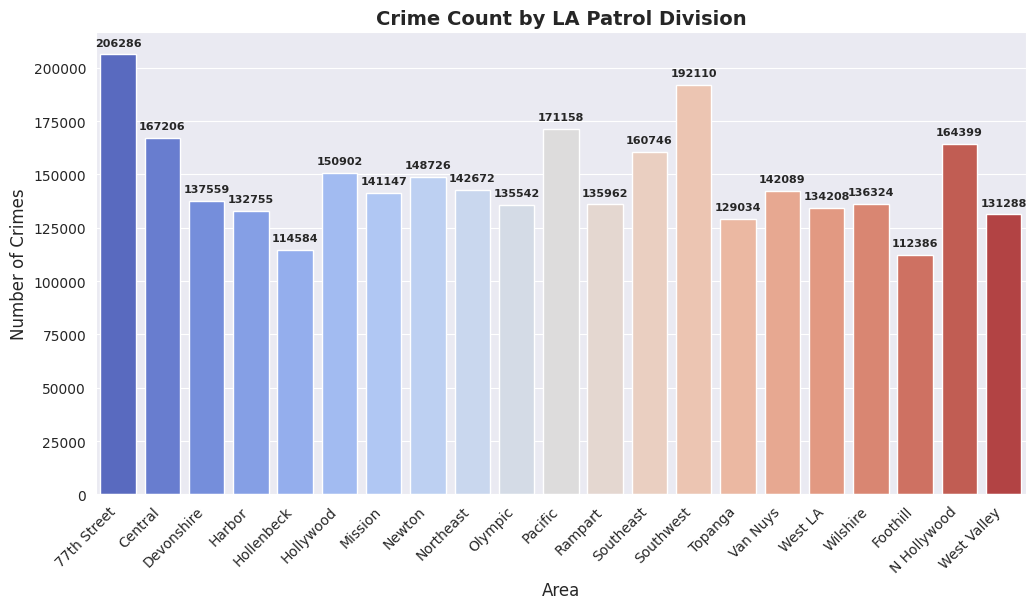

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

# 1. Crime Count per Area (Bar Plot)
plt.figure(figsize=(12, 6))
ax1 = sns.barplot(x=crimes_per_area.index, y=crimes_per_area.values, palette="coolwarm")
plt.title("Crime Count by LA Patrol Division", fontsize=14, fontweight="bold")
plt.xlabel("Area", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)
plt.xticks(rotation=45, ha="right")

for index, value in enumerate(crimes_per_area.values):
    plt.text(index, value + max(crimes_per_area.values) * 0.02, str(value), ha="center", fontsize=8, fontweight="bold")

plt.show()

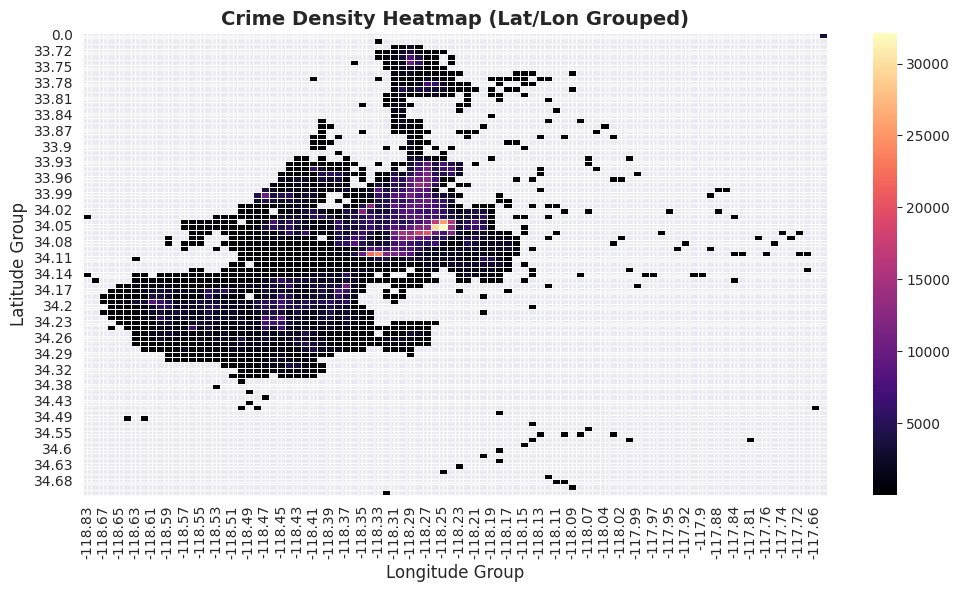

In [33]:
# 2. Crime Density Heatmap (Lat/Lon Grouped)
plt.figure(figsize=(12, 6))
crime_density = dataset.groupby(["Lat Group", "Lon Group"]).size().reset_index(name="Crime Count")
heatmap_data = crime_density.pivot(index="Lat Group", columns="Lon Group", values="Crime Count")

sns.heatmap(heatmap_data, cmap="magma", linewidths=0.5)
plt.title("Crime Density Heatmap (Lat/Lon Grouped)", fontsize=14, fontweight="bold")
plt.xlabel("Longitude Group", fontsize=12)
plt.ylabel("Latitude Group", fontsize=12)

plt.show()

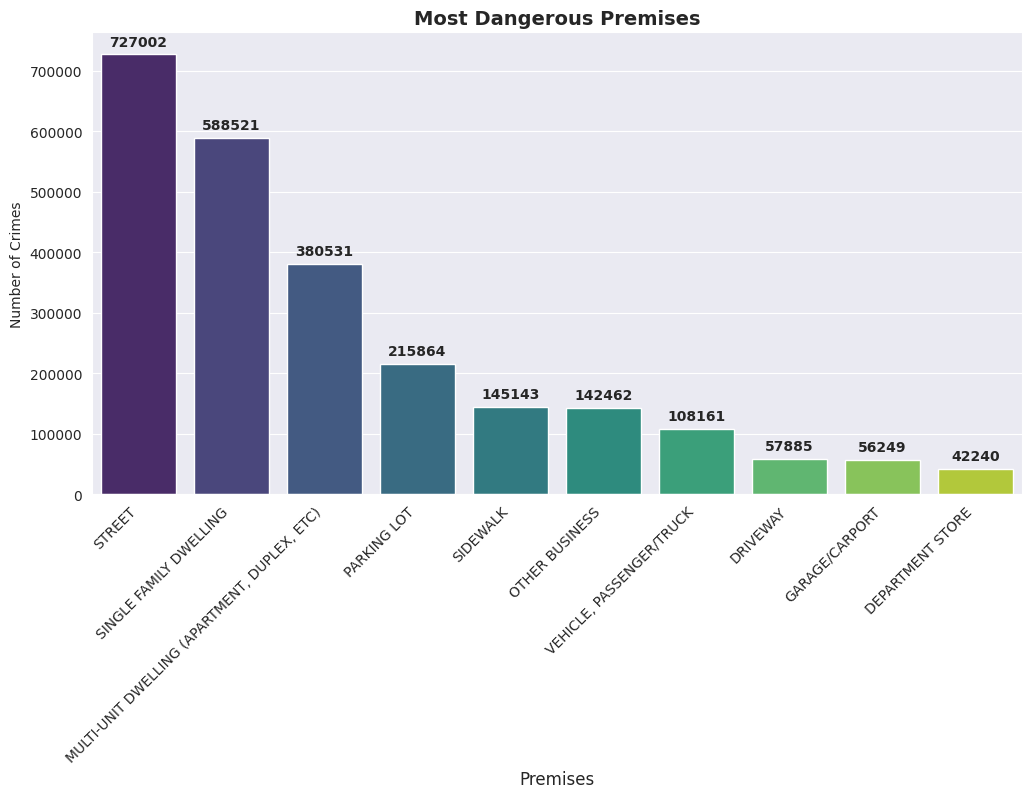

In [34]:
# 3. Top 10 Most Dangerous Premises
plt.figure(figsize=(12, 6))
top_premises = crimes_in_premis.sort_values(ascending=False).head(10)
ax3 = sns.barplot(x=top_premises.index, y=top_premises.values, palette="viridis")
plt.xticks(rotation=45, ha="right")

for index, value in enumerate(top_premises.values):
    plt.text(index, value + max(top_premises.values) * 0.02, str(value), ha="center", fontsize=10, fontweight="bold")
plt.title("Most Dangerous Premises", fontsize=14, fontweight="bold")
plt.xlabel("Premises", fontsize=12)
plt.ylabel("Number of Crimes")
plt.show()

Visualizing Based on Victim Attributes

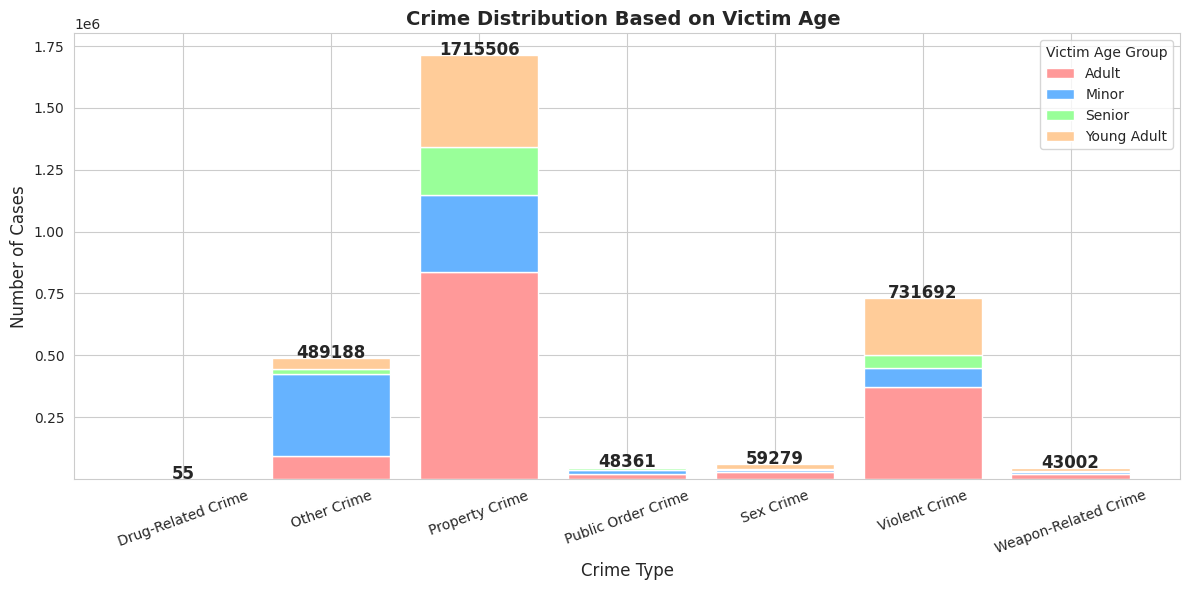

In [35]:
# Count occurrences of each Crime Type per Age Group
crime_age_group = dataset.groupby(["Crime Type", "Victim Age Group"]).size().unstack(fill_value=0)

# Set style
sns.set_style("whitegrid")

# Stacked Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

# Define colors for age groups
colors = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"]  # Minor, Young Adult, Adult, Senior

# Plot each age group as a stacked bar
bottom_values = [0] * len(crime_age_group.index)
age_groups = crime_age_group.columns

for i, age_group in enumerate(age_groups):
    ax.bar(crime_age_group.index, crime_age_group[age_group], bottom=bottom_values,
           color=colors[i], label=age_group)
    bottom_values = [bottom_values[j] + crime_age_group[age_group][j] for j in range(len(crime_age_group.index))]

# Labels and title
ax.set_title("Crime Distribution Based on Victim Age ", fontsize=14, fontweight="bold")
ax.set_xlabel("Crime Type", fontsize=12)
ax.set_ylabel("Number of Cases", fontsize=12)
ax.legend(title="Victim Age Group")


# Annotate values on bars
for i, crime in enumerate(crime_age_group.index):
    total = sum(crime_age_group.loc[crime])  # Sum of all age groups
    ax.text(i, total + 0.5, str(total), ha="center", fontsize=12, fontweight="bold")

# Show plot
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

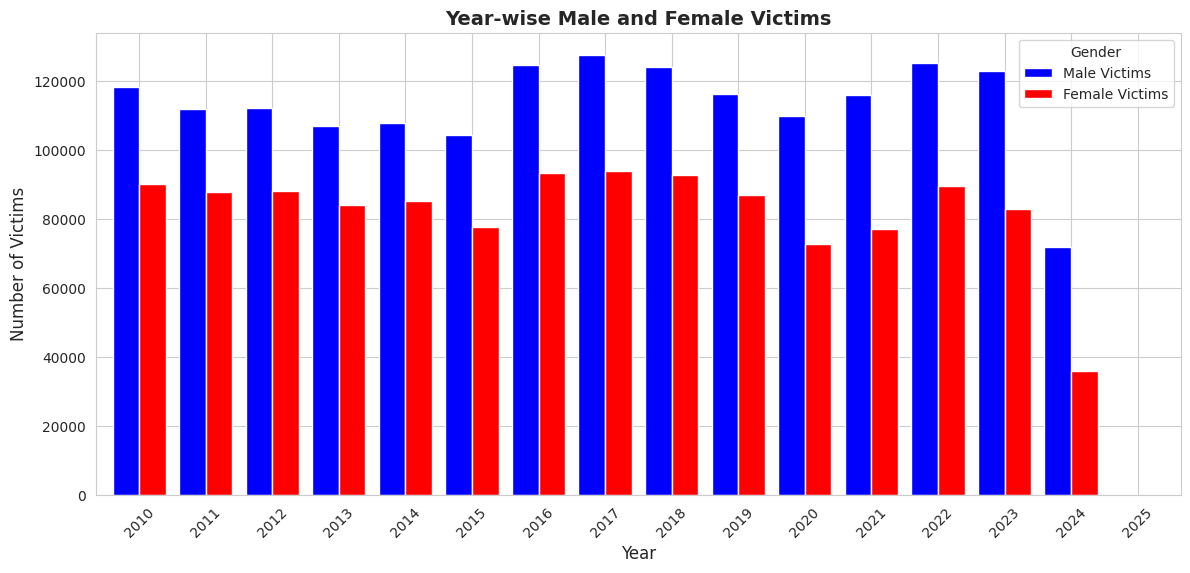

In [36]:
victims = pd.DataFrame({
    "Male Victims": male_victims,
    "Female Victims": female_victims
})

plt.figure(figsize=(12, 6))
ax = victims.plot(kind="bar", width=0.8, figsize=(14, 6), color=["blue", "red"])

plt.title("Year-wise Male and Female Victims", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Victims", fontsize=12)

plt.xticks(rotation=45)

plt.legend(title="Gender", loc="upper right")

plt.show()

In [37]:
# Mapping dictionary for descent codes
descent_dict = {
    'A': "Other Asian", 'B': "Black", 'C': "Chinese", 'D': "Cambodian", 'F': "Filipino",
    'G': "Guamanian", 'H': "Hispanic/Latin/Mexican", 'I': "American Indian/Alaskan",
    'J': "Japanese", 'K': "Korean", 'L': "Laotian", 'O': "Other", 'P': "Pacific Islander",
    'S': "Samoan", 'U': "Hawaiian", 'V': "Vietnamese", 'W': "White", 'X': "Unknown", 'Z': "Asian Indian"
}

# Map descent codes to full names using `.get()` inside `.map()`
descent_labels = victim_descent.index.map(lambda x: descent_dict.get(x))

In [38]:
# Rename index using the dictionary mapping directly
descent_victims = descent_victims.rename(index=descent_dict)

# Display the first 19 rows
print(descent_victims.head(19))


                           Male  Female
Vict Descent                           
Other Asian               35573   35790
Black                    265997  268545
Chinese                    2899    2772
Cambodian                    61      53
Filipino                   3638    3661
Guamanian                    66      86
Hispanic/Latin/Mexican   650933  512253
American Indian/Alaskan    1207     750
Japanese                    981    1009
Korean                     7487    6827
Other                    181054   96033
Pacific Islander            283     342
Hawaiian                    218     178
Vietnamese                  670     725
White                    520046  303893
Unknown                   27671    3970
Samoan                       45      41
Asian Indian                455     257
Laotian                      35      61


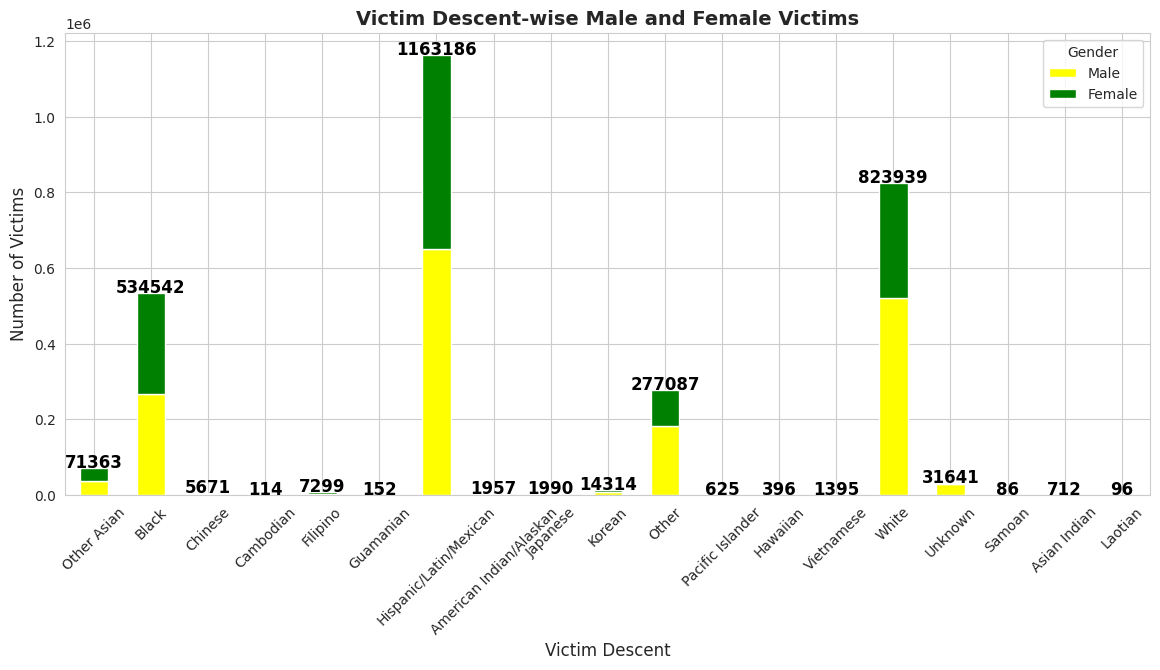

In [39]:
# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
descent_victims.plot(kind="bar", stacked=True, color=["yellow", "green"], ax=ax)

# Labels & Title
plt.title("Victim Descent-wise Male and Female Victims", fontsize=14, fontweight="bold")
plt.xlabel("Victim Descent", fontsize=12)
plt.ylabel("Number of Victims", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Gender")

# Annotate values on bars
for i, crime in enumerate(descent_victims.index):
    total = descent_victims.loc[crime].sum()  # Sum male + female victims for each descent
    ax.text(i, total + 500, str(total), ha="center", fontsize=12, fontweight="bold", color="black")

plt.show()

Visualizing Based  Crime Types

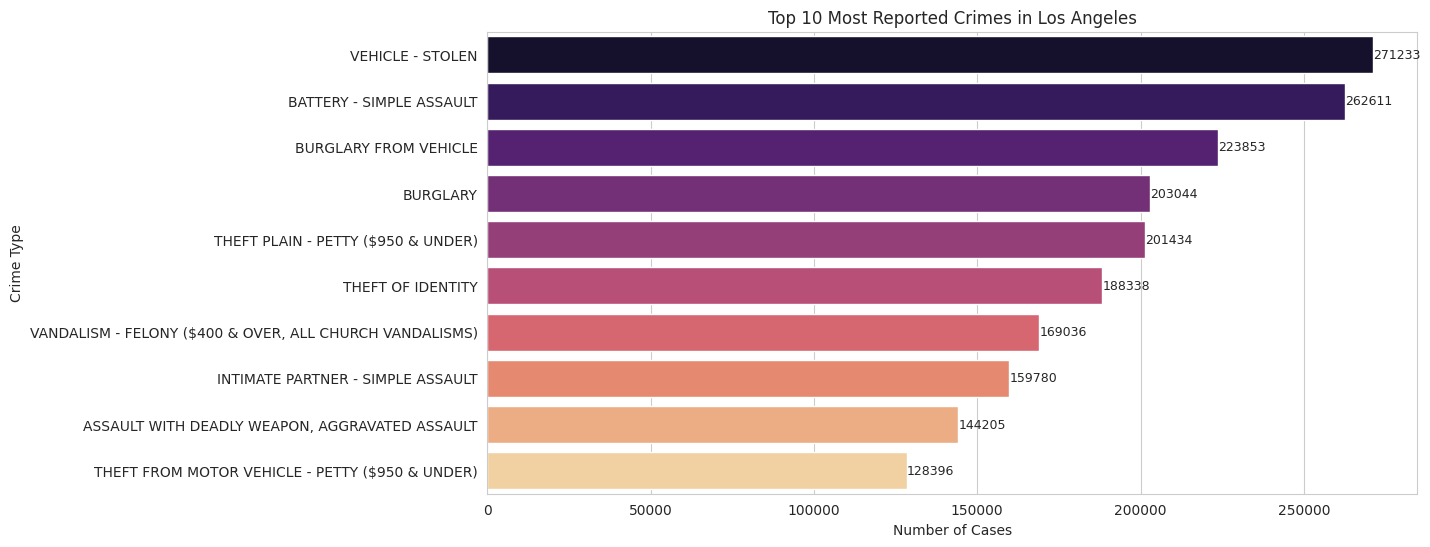

In [40]:
#Visualizing Top 10 Crimes
crime_counts = dataset['Crm Cd Desc'].value_counts()
top_crimes = crime_counts.head(10)

plt.figure(figsize=(12,6))
ax = sns.barplot(y=top_crimes.index, x=top_crimes.values, palette="magma")

# Adding count  on each bar
for index, value in enumerate(top_crimes.values):
    ax.text(value + 50, index, str(value), va='center', fontsize=9)


plt.xlabel("Number of Cases")
plt.ylabel("Crime Type")
plt.title("Top 10 Most Reported Crimes in Los Angeles")
plt.show()